# 12 · Geometry that makes reliable decisions

**Time:** 90–110 minutes. **Preparation:** interval arithmetic, Arb, determinants. **Lab:** [An orientation filter](../labs/lab12_robust_geometry.ipynb).

Objectives: turn a determinant enclosure into a geometric decision, escalate precision when useful, and fall back to exact arithmetic for exact inputs. This is the final core programming lab; allow time to discuss capstones.

In [1]:
from fractions import Fraction
import matplotlib.pyplot as plt
from IPython.display import display
from vc.intervals import RationalInterval as Interval
from vc.geometry import determinant, orientation, orientation_bound, sign_of_interval

## THEORY · Orientation is a sign question

For points A, B, C in the plane, define

$$D=(B_x-A_x)(C_y-A_y)-(B_y-A_y)(C_x-A_x).$$

If D>0, C lies to the left of the directed line from A to B; if D<0, it lies to the right. If D=0, the points are collinear, including degenerate cases where points coincide. D is twice the signed area of the triangle. Swapping B and C reverses its sign.

A geometric algorithm may use this sign to choose a branch. A small arithmetic error near zero can therefore change its combinatorial decision, not just the last digit of a coordinate.

Determinant: 2


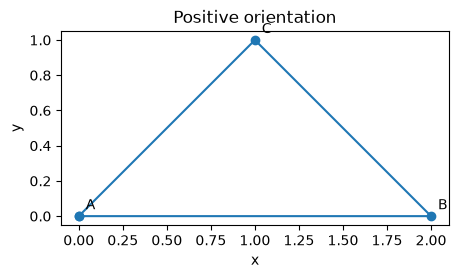

In [2]:
A, B, C_point = (0, 0), (2, 0), (1, 1)
print("Determinant:", determinant(A, B, C_point))
fig, ax = plt.subplots(figsize = (5, 3))
ax.plot([0, 2, 1, 0], [0, 0, 1, 0], "o-")
for name, point in [("A", A), ("B", B), ("C", C_point)]:
    ax.annotate(name, point, xytext = (5, 5), textcoords = "offset points")
ax.set(xlabel = "x", ylabel = "y", title = "Positive orientation")
ax.set_aspect("equal")
display(fig)
plt.close(fig)

## EXPERIMENT · Exactly represented inputs, wrong zero

Let n=2²⁷ and use A=(0,0), B=(n,n−1), C=(n+1,n). Every input coordinate is exactly representable in binary64. The exact determinant is n²−(n−1)(n+1)=1, but the two products round to the same binary64 value. This failure is arithmetic cancellation, without any input-conversion ambiguity.

In [3]:
n = 2 ** 27
points = ((0, 0), (n, n - 1), (n + 1, n))
float_points = [tuple(float(value) for value in point) for point in points]
naive = determinant(*float_points)
exact = determinant(*points)
print("Float determinant:", naive)
print("Exact determinant:", exact)
assert naive == 0 and exact == 1

Float determinant: 0.0
Exact determinant: 1


## THEORY · A filter answers only when its bound decides

Construct enclosing balls for all exact coordinates, evaluate the determinant through Arb, and convert its result to exact rational endpoints. A strictly positive or negative enclosure proves the corresponding sign. The exact singleton [0,0] proves zero. Every other zero-containing bound is inconclusive.

**Proof:** the determinant of the stated points belongs to the computed enclosure by compositional inclusion. An interval entirely on one side of zero determines its sign. Containing zero does not make the true value zero.

If the first bound is inconclusive, repeat from the exact input at a higher precision. If the configured list is exhausted, evaluate the determinant with `Fraction`. For finite exact rational inputs this supplies its exact sign, including collinearity. It is a fallback for a specified exact problem.

In [4]:
result = orientation(*points)
for precision, bound in result.attempts:
    print(precision, "bits:", bound)
print("Decision:", result.sign, "method:", result.method)
assert result.sign == 1

fallback = orientation(*points, precisions = (24,))
print("Short precision budget:", fallback.method, fallback.exact_determinant)
assert fallback.method == "fraction" and fallback.exact_determinant == 1
collinear = orientation((0, 0), ("1/3", "2/3"), ("2/3", "4/3"))
print("Collinear case:", collinear.sign, collinear.method)
assert collinear.sign == 0

24 bits: [-2147483672, 4294967320]
53 bits: [0, 4]
100 bits: [1, 1]
Decision: 1 method: arb
Short precision budget: fraction 1
Collinear case: 0 fraction


Read [vc/geometry.py](../vc/geometry.py). The filter keeps its attempted precisions and bounds in the result. It rejects implicit float input: use exact decimal strings for intended decimals, or explicitly convert a stored binary float with `Fraction.from_float` when that is the chosen input semantics.

**CHECKPOINT (10 minutes):** why is an arbitrary tolerance such as “abs(D)<10⁻¹⁰ means collinear” not a reliable exact orientation predicate? What happens under coordinate rescaling?

## Failure of a proposed repair · Measurements remain uncertain

Suppose A=(0,0), B=(1,1), and C has x=2 but y in [1.999,2.001]. Both clockwise and counterclockwise triples are physically allowed. No number of arithmetic digits can certify one uniform sign for this entire family.

Use `orientation_bound` for interval coordinates and report its sign test. Do not replace measured intervals by their midpoints and call the exact fallback: that changes the problem.

In [5]:
a = (Interval(0), Interval(0))
b = (Interval(1), Interval(1))
c = (Interval(2), Interval("1.999", "2.001"))
for precision in [24, 100, 200]:
    bound = orientation_bound(a, b, c, precision)
    print(precision, bound, "sign:", sign_of_interval(bound))
    assert bound.lo < 0 < bound.hi
print("Allowed negative determinant:", determinant((0, 0), (1, 1), (2, Fraction("1.999"))))
print("Allowed positive determinant:", determinant((0, 0), (1, 1), (2, Fraction("2.001"))))

24 [-137461761/137438953472, 137461761/137438953472] sign: None
100 [-274877909/274877906944, 274877909/274877906944] sign: None
200 [-274877909/274877906944, 274877909/274877906944] sign: None
Allowed negative determinant: -1/1000
Allowed positive determinant: 1/1000


## Application scope and capstone bridge

A correct orientation predicate supports reliable decisions in geometry algorithms, but it does not prove an entire triangulation or collision simulator correct. Coverage, degeneracies, and other branch conditions need their own arguments.

The [mirror project](../projects/mirror_trajectory.ipynb) uses the same discipline for a more involved decision: which circle is hit first? Its reflection formula alone is insufficient without certified collision ordering.

**Reading:** J. R. Shewchuk's [robust predicates introduction and papers](https://www.cs.cmu.edu/~quake/robust.html) explain the role of determinant signs and adaptive exact predicates in computational geometry. Our teaching filter uses Arb and rational fallback; it does not implement Shewchuk's expansion arithmetic.

**Exit ticket:** distinguish exact collinearity, a zero-containing arithmetic bound, and a family of uncertain inputs allowing several orientations. Next: [certificate audit](13_certificate_audit.ipynb).